# YEaaaw wassup

In [2]:
#Imports and other relevant stuff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.spatial import Delaunay
import scipy.interpolate as interpolate
import scipy.stats as stats
import statsmodels.api as sm

In [3]:
#Importing the data into DataFrames
boredata= pd.read_csv("https://github.com/Matei-Stoica-Uni/Capstone-Case-Study---Australia/blob/main/Data/recharge-australia_data-bores.csv?raw=true")
griddata= pd.read_csv("https://github.com/Matei-Stoica-Uni/Capstone-Case-Study---Australia/blob/main/Data/recharge-australia_data-gridded.csv?raw=true")

In [4]:
boredata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98568 entries, 0 to 98567
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Bore_ID                 98568 non-null  object 
 1   State                   98568 non-null  object 
 2   Longitude               98568 non-null  float64
 3   Latitude                98568 non-null  float64
 4   Elevation               98568 non-null  float64
 5   Distance_to_coast       98568 non-null  float64
 6   Rainfall                98568 non-null  float64
 7   Seasonal_rainfall_zone  98568 non-null  object 
 8   Runoff_coefficient      98568 non-null  float64
 9   PET                     98568 non-null  float64
 10  NDVI                    98568 non-null  float64
 11  Soil_class              98568 non-null  object 
 12  Clay_fraction           98568 non-null  float64
 13  Recharge_rate           98568 non-null  float64
dtypes: float64(10), object(4)
memory usage

In [5]:
griddata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277090 entries, 0 to 277089
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Longitude               277090 non-null  float64
 1   Latitude                277090 non-null  float64
 2   Elevation               277090 non-null  float64
 3   Distance_to_coast       277090 non-null  float64
 4   Rainfall                277090 non-null  float64
 5   Seasonal_rainfall_zone  277090 non-null  object 
 6   PET                     277090 non-null  float64
 7   NDVI                    277090 non-null  float64
 8   Soil_class              277090 non-null  object 
 9   Clay_fraction           277090 non-null  float64
dtypes: float64(8), object(2)
memory usage: 21.1+ MB


Some info about the datasets' variables:

Borehole data:
- Bore_ID: str, should be int, not very tidy, repeated/incomplete ID numbers, some even with letters in them. Not very relevant data for us here.
- State: str, has 7 unique values (Queensland, Tasmania, Victoria, Western Australia, South Australia, New South Wales, Northern Territory). Does not seem particularly relevant here.
- Longitude [°E]: float, min=113.6535995, max=153.583287 
- Latitude [°N]: float, min=-43.411719 ,max=-11.0654695
- Elevation [m]: float, min=-26.0 ,max=1434.0. (wrt Australian Height Datum)
  Lon, lat and elev are location data, relevant here.
- Distance_to_coast [km]: float min=1.000235932, max= 926.703683. Distance to coast could indicate how much moisture from the sea the ground is getting, maybe relevant here.
- Rainfall [mm/yr]: float, min=108.5781, max=4231.02524, very relevant here, probably very strongly correlated with groundwater recharge
- Seasonal_rainfall_zone: str, has 20 unique values, but is a combination of the seasonality (summer, winter, uniform, +dominant) and rainfall amount ( less than 250 to more than 1200 mm/yr). Unkown relevance, will have to process more as well to transform to numerical data for model.
- Runoff coefficient: float, min=0.00041, max=0.74112, the higher it is, the less permeable the surface is, the lower it is, the more permeable it is. Relevant here.
- PET (Potential EvapoTranspiration) [mm/yr]: float, min= 1113.36244, max=3068.18368. Relevant for sure, but how much ? Maybe combine with precipitation to get some other variable ?
- NDVI (Normalized Difference Vegetation Index): float, between -1 and +1, with +1 being very healthy and dense vegetation, and 0 being barren soil, negative values are used for non-land stuff

In [7]:
set_of_test_points_lon = np.array(boredata['Longitude'])
set_of_test_points_lat = np.array(boredata['Latitude'])
set_of_test_points_recharge_rate = np.array(boredata['Recharge_rate'])
set_of_test_points = np.c_[set_of_test_points_lon, set_of_test_points_lat]

set_of_test_points_gridded_lon = np.array(griddata['Longitude'])
set_of_test_points_gridded_lat = np.array(griddata['Latitude'])

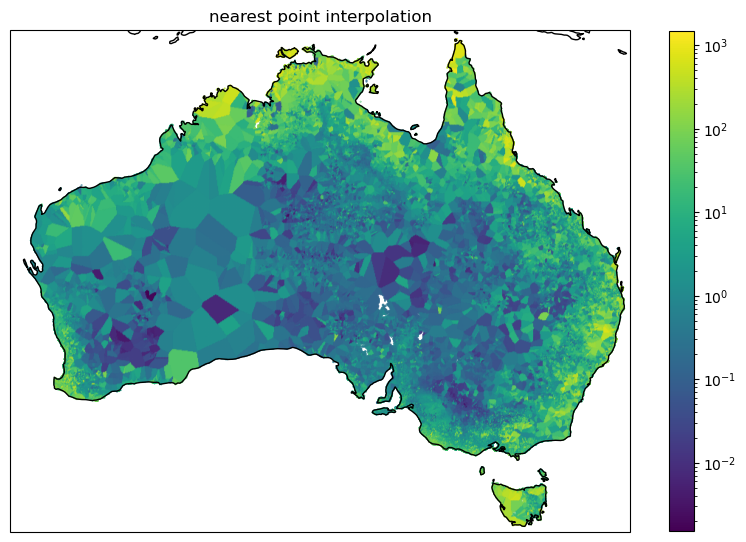

In [6]:
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cfeature.LAND)
#ax.add_feature(cfeature.BORDERS)
#ax.add_feature(cfeature.COASTLINE)
ax.scatter(set_of_test_points_lon, set_of_test_points_lat,s=1, norm=colors.LogNorm(), c=set_of_test_points_recharge_rate, cmap='viridis')
interp_nearest = interpolate.NearestNDInterpolator(set_of_test_points, set_of_test_points_recharge_rate)
cax = ax.scatter(set_of_test_points_gridded_lon, set_of_test_points_gridded_lat, s=0.1, norm=colors.LogNorm(), c=interp_nearest(set_of_test_points_gridded_lon, set_of_test_points_gridded_lat), cmap='viridis')
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
plt.colorbar(cax, shrink=0.65)
plt.title('nearest point interpolation')
plt.show()

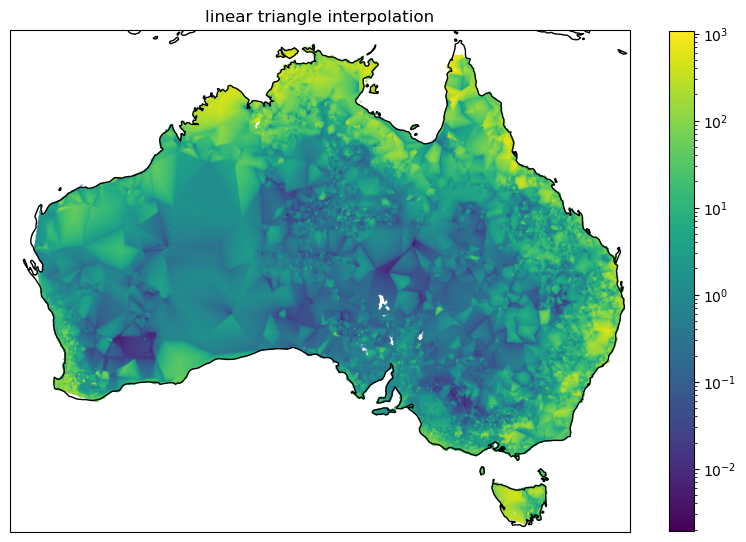

In [7]:
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cfeature.LAND)
#ax.add_feature(cfeature.BORDERS)
#ax.add_feature(cfeature.COASTLINE)
ax.scatter(set_of_test_points_lon, set_of_test_points_lat,s=1, norm=colors.LogNorm(), c=set_of_test_points_recharge_rate, cmap='viridis')
interp = interpolate.LinearNDInterpolator(set_of_test_points, set_of_test_points_recharge_rate)
cax = ax.scatter(set_of_test_points_gridded_lon, set_of_test_points_gridded_lat, s=0.1, norm=colors.LogNorm(), c=interp(set_of_test_points_gridded_lon, set_of_test_points_gridded_lat), cmap='viridis')
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
plt.colorbar(cax, shrink=0.65)
plt.title('linear triangle interpolation')
plt.show()

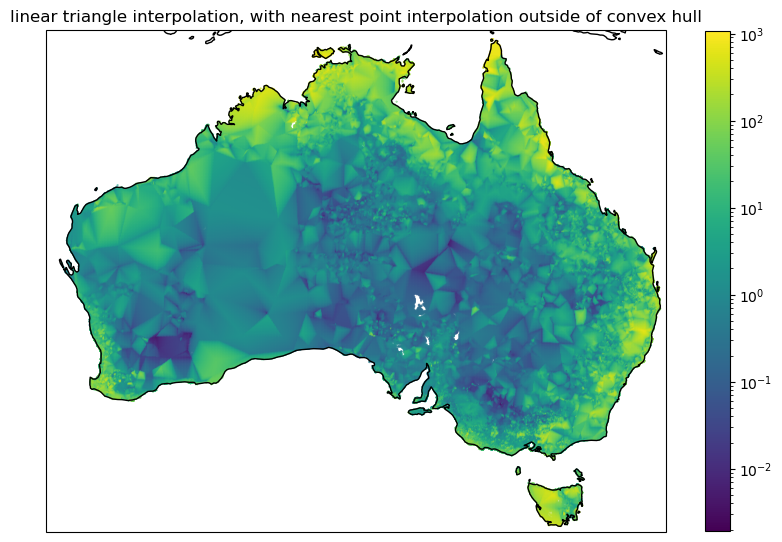

In [8]:
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cfeature.LAND)
#ax.add_feature(cfeature.BORDERS)
#ax.add_feature(cfeature.COASTLINE)
ax.scatter(set_of_test_points_lon, set_of_test_points_lat,s=1, norm=colors.LogNorm(), c=set_of_test_points_recharge_rate, cmap='viridis')
interp = interpolate.LinearNDInterpolator(set_of_test_points, set_of_test_points_recharge_rate, fill_value=99999999)
interp_values = []
for i in range(len(set_of_test_points_gridded_lon)):
    if interp(set_of_test_points_gridded_lon[i], set_of_test_points_gridded_lat[i]) == 99999999:
        interp_values.append(interp_nearest(set_of_test_points_gridded_lon[i], set_of_test_points_gridded_lat[i]))
        #print(f'fill value at {i}')
    else:
        interp_values.append(interp(set_of_test_points_gridded_lon[i], set_of_test_points_gridded_lat[i]))
cax = ax.scatter(set_of_test_points_gridded_lon, set_of_test_points_gridded_lat, s=0.1, norm=colors.LogNorm(), c=interp_values, cmap='viridis')
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
plt.colorbar(cax, shrink=0.65)
plt.title('linear triangle interpolation, with nearest point interpolation outside of convex hull')
plt.show()

[[36611 95403 33458]
 [88560 75953 88564]
 [16970 17244 15718]
 ...
 [31679 31708 31681]
 [31665 31712 31662]
 [31662 31712 31658]]


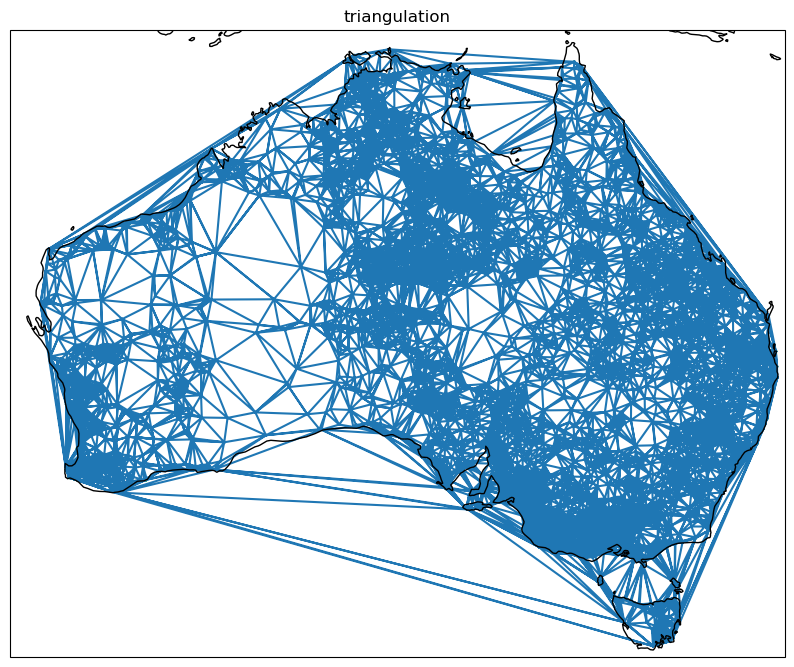

In [22]:
tri = Delaunay(set_of_test_points)
print(tri.simplices.copy())

plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cfeature.LAND)
#ax.add_feature(cfeature.BORDERS)
#ax.add_feature(cfeature.COASTLINE)
ax.scatter(set_of_test_points_lon, set_of_test_points_lat,s=1, norm=colors.LogNorm(), c=set_of_test_points_recharge_rate, cmap='viridis')
ax.triplot(set_of_test_points_lon,set_of_test_points_lat, tri.simplices.copy())
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
plt.title('triangulation')
plt.show()

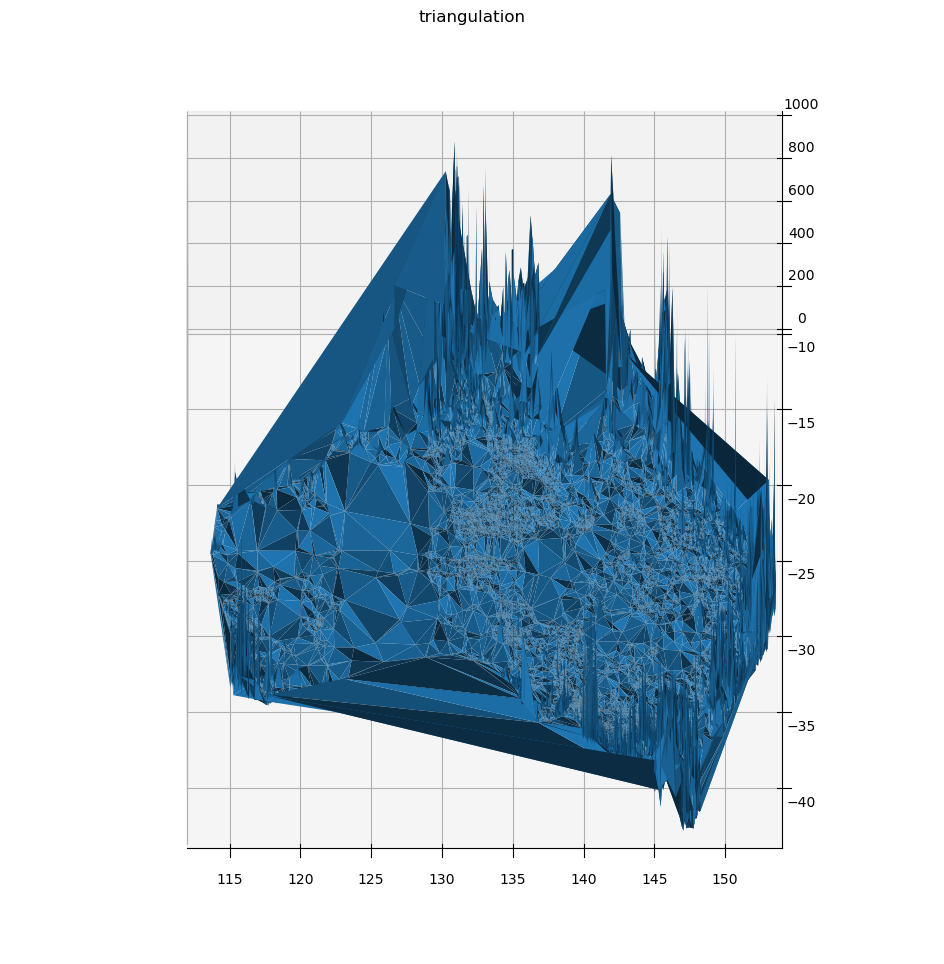

In [25]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')
ax.set_proj_type('ortho') #sets 3d projection to be orthographic so there is no perspective distortion 
ax.plot_trisurf(set_of_test_points_lon, set_of_test_points_lat, np.clip(set_of_test_points_recharge_rate,a_min=0,a_max=999), triangles=tri.simplices.copy())
ax.set_xlim(112,154)
ax.set_ylim(-44,-10)
ax.view_init(elev=60, azim=-90, roll=0)
plt.title('triangulation')
plt.show()

In [76]:

boredata_nostr= boredata.drop(labels=['Bore_ID', 'Seasonal_rainfall_zone', 'State', 'Soil_class'], axis=1)

boredata_str = boredata.drop(labels=['Bore_ID','State','Longitude', 'Latitude', 'Elevation', 'Distance_to_coast', 'Rainfall', 'Runoff_coefficient', 'PET', 'NDVI', 'Clay_fraction'], axis=1)
#making the seasonal rainfall zone data more clean. The rainfall data is already included in the rainfall column so that data can be removed and so only the seasonal data is kept.
boredata_str['Seasonal_rainfall_zone'] = boredata_str['Seasonal_rainfall_zone'].replace({'summer (650 - 1200 mm)': 'summer', 
                                                'arid (summer, less than 350 mm)': 'summer',
                                                'summer dominant (350 - 650 mm)': 'summer dominant',
                                                'summer (350 - 650 mm)': 'summer',
                                                'arid (summer dominant, less than 350 mm)': 'summer dominant',
                                                'summer dominant (650 - 1200 mm)': 'summer dominant',
                                                'arid (uniform, less than 250 mm)': 'uniform',
                                                'summer dominant (more than 1200 mm)': 'summer dominant',
                                                'summer (more than 1200 mm)': 'summer',
                                                'winter (more than 800 mm)': 'winter',
                                                'winter (500 - 800 mm)': 'winter',
                                                'winter dominant (more than 800 mm)': 'winter dominant',
                                                'winter (250 - 500 mm)': 'winter',
                                                'winter dominant (250 - 500 mm)': 'winter dominant',
                                                'winter dominant (500 - 800 mm)': 'winter dominant',
                                                'uniform (more than 800 mm)': 'uniform',
                                                'uniform (500 - 800 mm)': 'uniform',
                                                'arid (winter, less than 250 mm)': 'winter',
                                                'arid (winter dominant, less than 250 mm)': 'winter dominant',
                                                'uniform (250 - 500 mm)': 'uniform'})
boredata_str['Soil_class'].unique()

Seasonal_onehot = pd.get_dummies(boredata_str['Seasonal_rainfall_zone'])
Soil_class_onehot = pd.get_dummies(boredata_str['Soil_class'])
boredata_onehot = Seasonal_onehot
boredata_onehot = boredata_onehot.join(Soil_class_onehot)
pd.set_option('display.expand_frame_repr', False)
print(boredata_onehot)
pd.set_option('display.expand_frame_repr', True)

       summer  summer dominant  uniform  winter  winter dominant  Anthroposols  Calcarosols  Chromosols  Dermosols  Ferrosols  Hydrosols  Kandosols  Kurosols  Organosols  Podosols  Rudosols  Sodosols  Tenosols  Vertosols
0        True            False    False   False            False         False        False       False      False      False      False      False     False       False     False     False     False     False       True
1        True            False    False   False            False         False        False       False      False      False      False      False     False       False     False     False     False     False       True
2        True            False    False   False            False         False        False       False      False      False      False      False     False       False     False     False     False     False       True
3        True            False    False   False            False         False        False       False      False  

                                      Season  Recharge offset  Standard deviation
0                     summer (650 - 1200 mm)        27.494372           45.047863
1            arid (summer, less than 350 mm)         8.179234           32.451289
2             summer dominant (350 - 650 mm)        12.782059           29.682735
3                      summer (350 - 650 mm)         9.311137           16.138693
4   arid (summer dominant, less than 350 mm)         8.001742           16.992291
5            summer dominant (650 - 1200 mm)        63.248017           93.959759
6           arid (uniform, less than 250 mm)         0.941745            4.016899
7        summer dominant (more than 1200 mm)       277.419666          223.660222
8                 summer (more than 1200 mm)       166.981790          150.211957
9                  winter (more than 800 mm)        59.256183           78.263066
10                     winter (500 - 800 mm)        23.517055           42.723969
11        winter

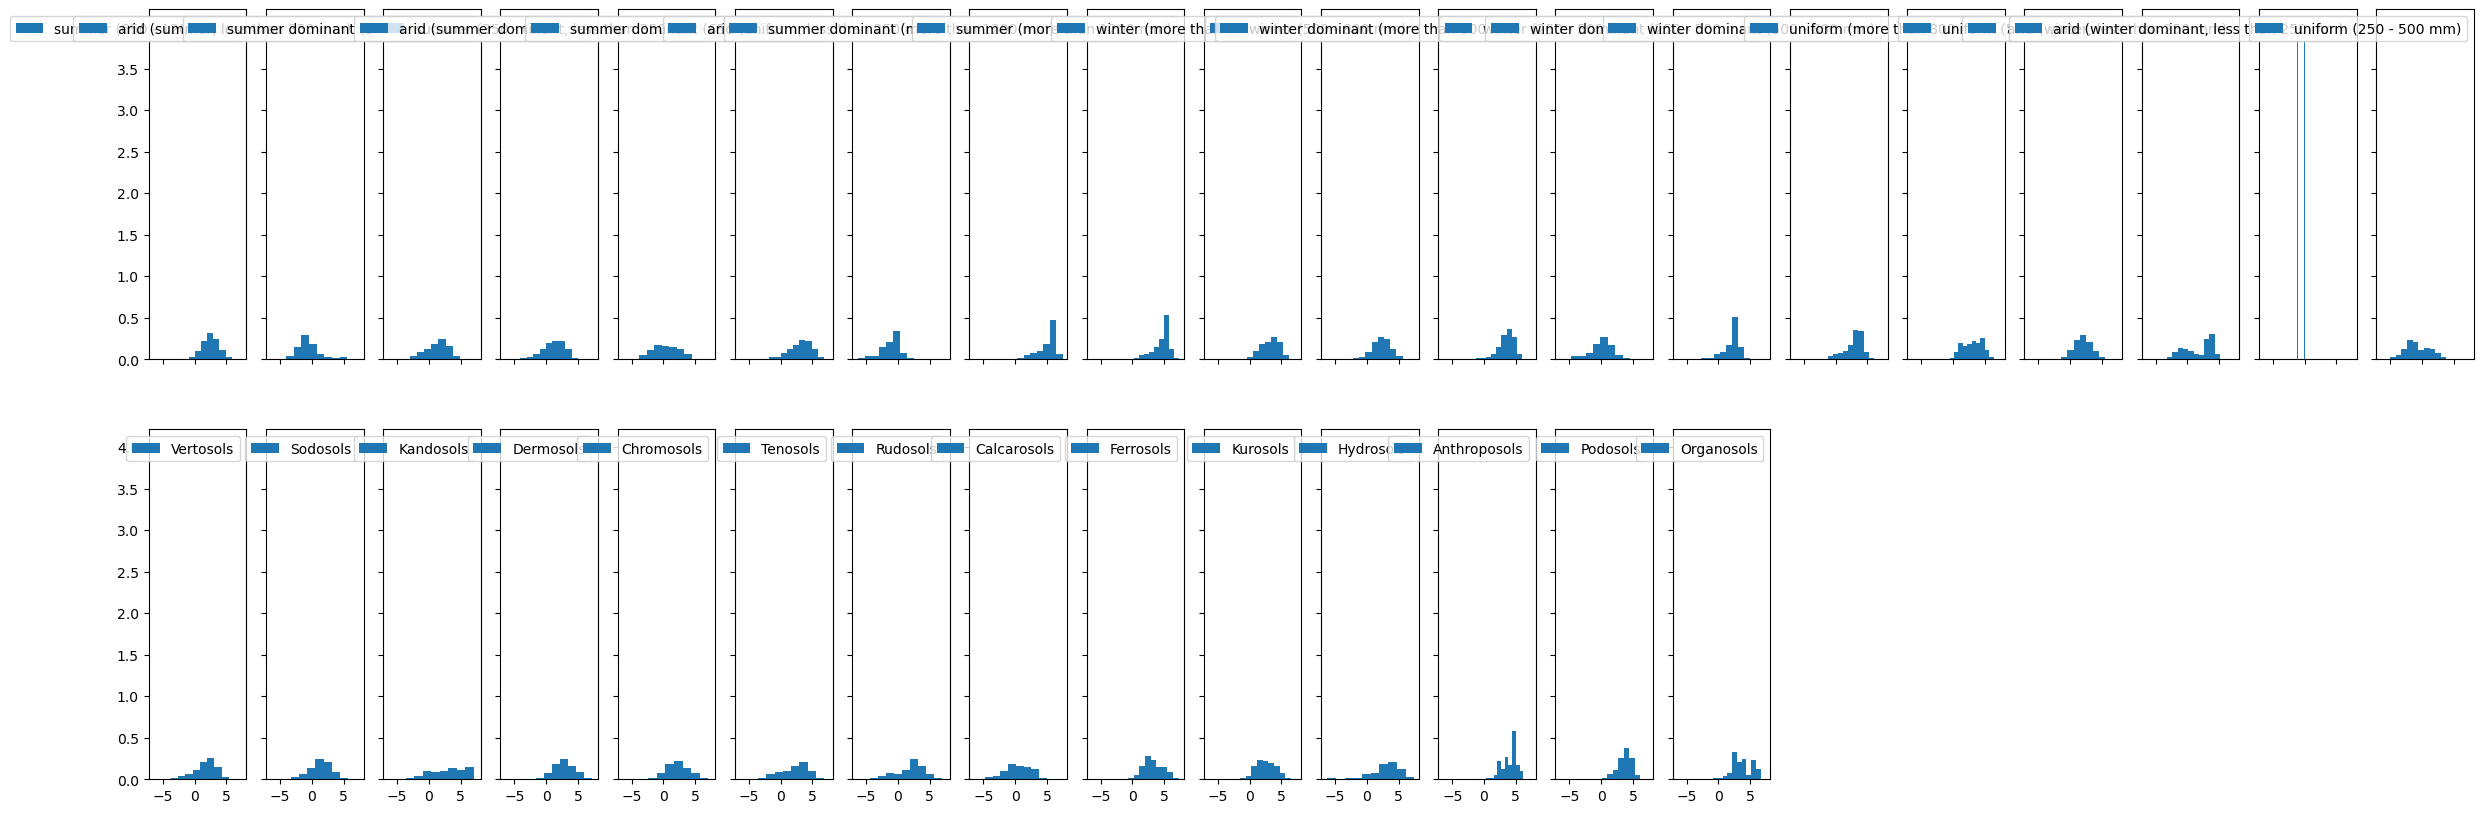

In [53]:
fig, ax = plt.subplots(2,20, figsize=(30,10), sharey=True, sharex=True)
for axes in ax.flat:
    axes.set_visible(False)


seasonal_recharge_offset = []
for i, Season in zip(range(len(boredata_str['Seasonal_rainfall_zone'].unique())),boredata_str['Seasonal_rainfall_zone'].unique()):
    seasonal_boredata = boredata_str[boredata_str['Seasonal_rainfall_zone']==Season]
    ax[0,i].hist(np.log(seasonal_boredata['Recharge_rate']), label=Season, density=True)
    ax[0,i].legend()
    ax[0,i].set_visible(True)
    seasonal_recharge_offset.append([Season,np.mean(seasonal_boredata['Recharge_rate']), np.std(seasonal_boredata['Recharge_rate'],ddof=1)])

seasonal_recharge_offset_summary = pd.DataFrame(seasonal_recharge_offset,columns=['Season', 'Recharge offset', 'Standard deviation'])


soil_class_recharge_offset = []
for i, Soil in zip(range(len(boredata_str['Soil_class'].unique())),boredata_str['Soil_class'].unique()):
    soil_class_boredata = boredata_str[boredata_str['Soil_class']==Soil]
    ax[1,i].hist(np.log(soil_class_boredata['Recharge_rate']), label=Soil, density=True)
    ax[1,i].legend()
    ax[1,i].set_visible(True)
    soil_class_recharge_offset.append([Soil,np.mean(soil_class_boredata['Recharge_rate']), np.std(soil_class_boredata['Recharge_rate'],ddof=1)])

soil_class_recharge_offset_summary = pd.DataFrame(soil_class_recharge_offset,columns=['Soil_class', 'Recharge offset', 'Standard deviation'])
pd.set_option('display.expand_frame_repr', False)
print(seasonal_recharge_offset_summary)
print(soil_class_recharge_offset_summary)
pd.set_option('display.expand_frame_repr', True)

array([[<Axes: xlabel='Longitude', ylabel='Longitude'>,
        <Axes: xlabel='Latitude', ylabel='Longitude'>,
        <Axes: xlabel='Elevation', ylabel='Longitude'>,
        <Axes: xlabel='Distance_to_coast', ylabel='Longitude'>,
        <Axes: xlabel='Rainfall', ylabel='Longitude'>,
        <Axes: xlabel='Runoff_coefficient', ylabel='Longitude'>,
        <Axes: xlabel='PET', ylabel='Longitude'>,
        <Axes: xlabel='NDVI', ylabel='Longitude'>,
        <Axes: xlabel='Clay_fraction', ylabel='Longitude'>,
        <Axes: xlabel='Recharge_rate', ylabel='Longitude'>],
       [<Axes: xlabel='Longitude', ylabel='Latitude'>,
        <Axes: xlabel='Latitude', ylabel='Latitude'>,
        <Axes: xlabel='Elevation', ylabel='Latitude'>,
        <Axes: xlabel='Distance_to_coast', ylabel='Latitude'>,
        <Axes: xlabel='Rainfall', ylabel='Latitude'>,
        <Axes: xlabel='Runoff_coefficient', ylabel='Latitude'>,
        <Axes: xlabel='PET', ylabel='Latitude'>,
        <Axes: xlabel='NDVI', yla

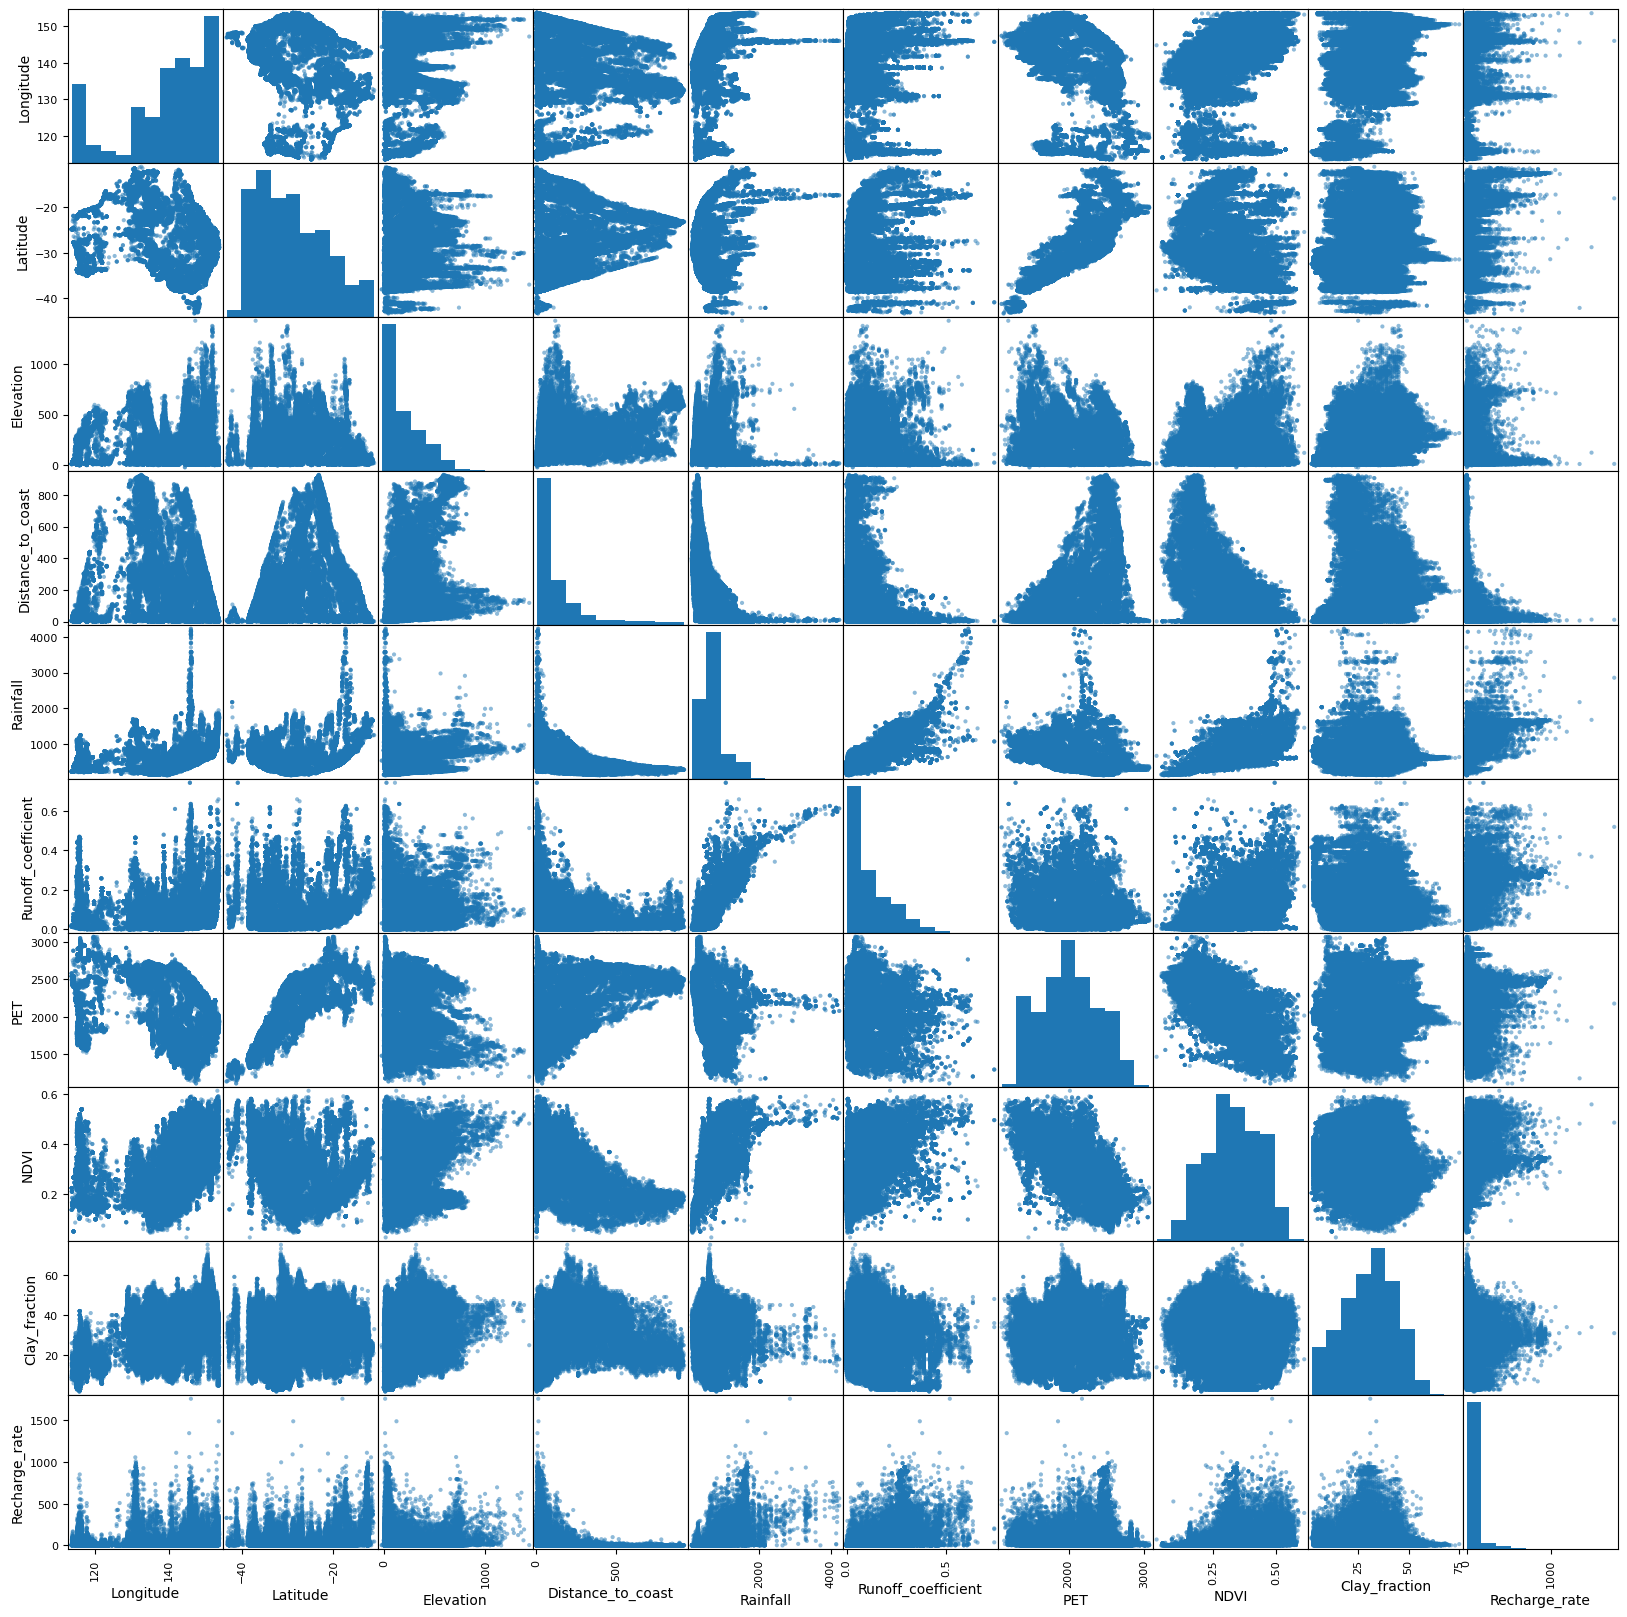

In [54]:
pd.plotting.scatter_matrix(boredata_nostr, figsize=(20,20))

In [55]:
boredata_nostr= boredata.drop(labels=['Bore_ID', 'Seasonal_rainfall_zone', 'State', 'Soil_class'], axis=1)
boredata_nostr.corr(method='pearson')

,Longitude,Latitude,Elevation,Distance_to_coast,Rainfall,Runoff_coefficient,PET,NDVI,Clay_fraction,Recharge_rate
Longitude,1.000000,-0.067339,0.181260,0.010499,0.147034,-0.131391,-0.275426,0.346792,0.707189,-0.081989
Latitude,-0.067339,1.000000,0.034565,0.204309,0.338926,0.284006,0.873718,-0.368410,0.135768,0.362821
Elevation,0.181260,0.034565,1.000000,0.520448,-0.253907,-0.260121,0.048579,-0.126690,0.315409,-0.146367
Distance_to_coast,0.010499,0.204309,0.520448,1.000000,-0.474349,-0.388185,0.426594,-0.524181,0.052669,-0.223828
Rainfall,0.147034,0.338926,-0.253907,-0.474349,1.000000,0.780634,-0.061958,0.562433,0.093830,0.620615
Runoff_coefficient,-0.131391,0.284006,-0.260121,-0.388185,0.780634,1.000000,0.021943,0.293213,-0.147173,0.469587
PET,-0.275426,0.873718,0.048579,0.426594,-0.061958,0.021943,1.000000,-0.687191,-0.029542,0.115113
NDVI,0.346792,-0.368410,-0.126690,-0.524181,0.562433,0.293213,-0.687191,1.000000,0.153541,0.189530
Clay_fraction,0.707189,0.135768,0.315409,0.052669,0.093830,-0.147173,-0.029542,0.153541,1.000000,-0.040403
Recharge_rate,-0.081989,0.362821,-0.146367,-0.223828,0.620615,0.469587,0.115113,0.189530,-0.040403,1.000000


[Text(0, 0, 'Longitude'),
 Text(0, 1, 'Latitude'),
 Text(0, 2, 'Elevation'),
 Text(0, 3, 'Distance_to_coast'),
 Text(0, 4, 'Rainfall'),
 Text(0, 5, 'Runoff_coefficient'),
 Text(0, 6, 'PET'),
 Text(0, 7, 'NDVI'),
 Text(0, 8, 'Clay_fraction'),
 Text(0, 9, 'Recharge_rate')]

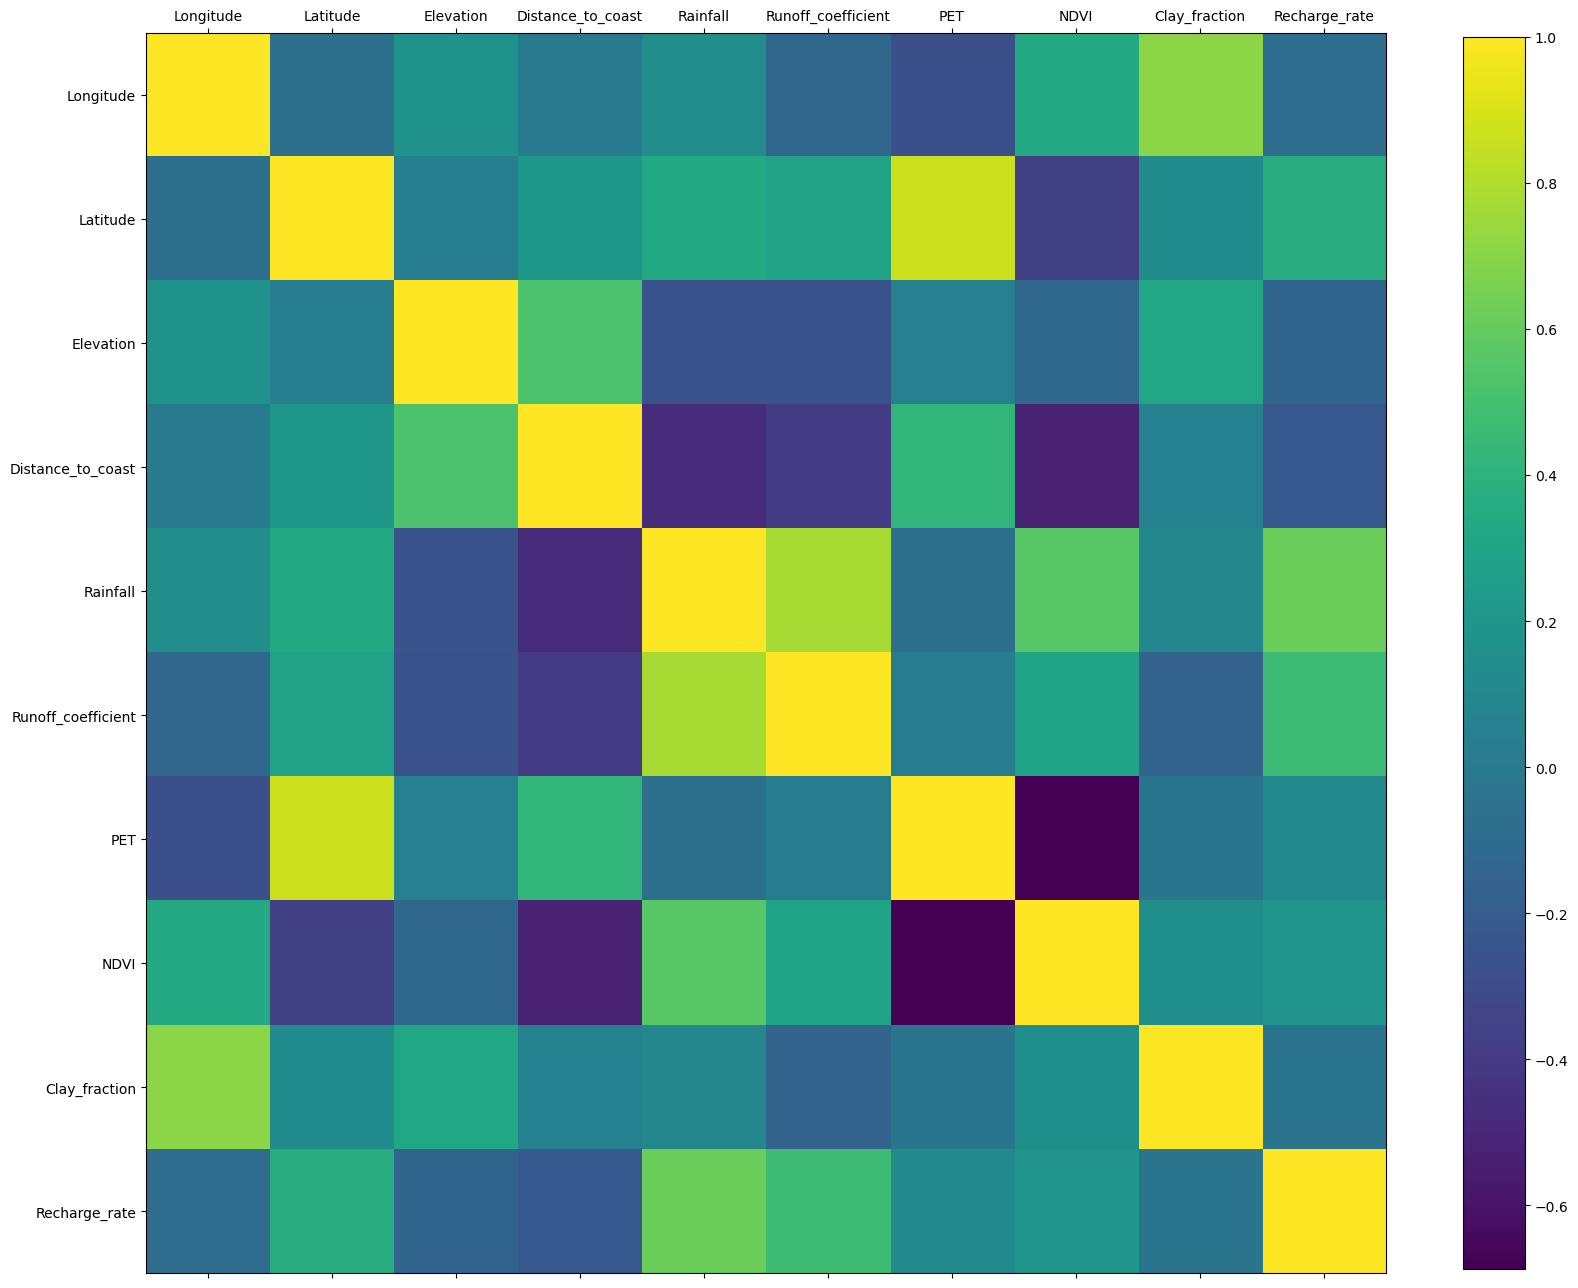

In [56]:
plt.figure(figsize=(20, 20))
ax = plt.axes()
cax = ax.matshow(boredata_nostr.corr(method='pearson'))
plt.colorbar(cax, shrink=0.80)
xaxis = np.arange(len(boredata_nostr.columns))
ax.set_xticks(xaxis)
ax.set_yticks(xaxis)
ax.set_xticklabels(boredata_nostr.columns)
ax.set_yticklabels(boredata_nostr.columns)

In [67]:
## simple linear model using all numerical variables
# y=np.array(boredata_nostr['Recharge_rate'])
# X=[]
# for i in range(len(boredata_nostr['Longitude'])):
#     X_intermediate = [1]
#     for j in list(boredata_nostr.columns):
#         if j != 'Recharge_rate':
#             X_intermediate.append(np.array(boredata[j])[i])
#     X.append(X_intermediate)

y=np.array(boredata_nostr['Recharge_rate'])
X_all_numerical = pd.DataFrame(np.array([1]*len(boredata_nostr)),columns=['Constant'])
X_all_numerical = X_all_numerical.join(boredata_nostr)
X_all_numerical = X_all_numerical.drop(labels=['Recharge_rate'], axis=1)
X_all_numerical = X_all_numerical.astype(float)
X_all_numerical


,Constant,Longitude,Latitude,Elevation,Distance_to_coast,Rainfall,Runoff_coefficient,PET,NDVI,Clay_fraction
0,1.0,150.152475,-25.016191,156.0,170.370517,661.51238,0.05773,2261.66309,0.28492,49.0
1,1.0,150.161641,-24.972302,183.0,165.576783,659.19571,0.12237,2271.36634,0.26382,49.0
2,1.0,150.148864,-24.962858,164.0,165.192429,659.19571,0.12237,2271.36634,0.26382,50.0
3,1.0,150.152197,-24.985357,171.0,167.292281,661.51238,0.05773,2261.66309,0.28492,48.0
4,1.0,150.137753,-24.975636,162.0,166.956511,661.51238,0.05773,2261.66309,0.28492,50.0
...,...,...,...,...,...,...,...,...,...,...
98563,1.0,146.066731,-38.102658,97.0,52.704905,957.91476,0.15651,1410.98355,0.53738,46.0
98564,1.0,146.066698,-38.102704,97.0,52.699778,957.91476,0.15651,1410.98355,0.53738,46.0
98565,1.0,146.012921,-38.147908,121.0,46.103775,946.12429,0.14670,1410.90813,0.54740,44.0
98566,1.0,146.012921,-38.147908,121.0,46.103775,946.12429,0.14670,1410.90813,0.54740,44.0


In [58]:
model_multi = sm.OLS(y, X_all_numerical)
results = model_multi.fit()
print(results.summary())
model_multi_log = sm.OLS(np.log(y), X_all_numerical)
results = model_multi_log.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.475
Model:                            OLS   Adj. R-squared:                  0.475
Method:                 Least Squares   F-statistic:                     9902.
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        19:00:54   Log-Likelihood:            -5.6227e+05
No. Observations:               98568   AIC:                         1.125e+06
Df Residuals:                   98558   BIC:                         1.125e+06
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Constant             840.7407     12

In [77]:
## simple linear model using all variables including categorical (useing onehot encoding)
y=np.array(boredata_nostr['Recharge_rate'])
boredata_all = boredata_nostr.join(boredata_onehot)
X_all_variables = pd.DataFrame(np.array([1]*len(boredata_all)),columns=['Constant'])
X_all_variables = X_all_variables.join(boredata_all)
X_all_variables = X_all_variables.drop(labels=['Recharge_rate'], axis=1)
X_all_variables = X_all_variables.astype(float)
X_all_variables.columns

Index(['Constant', 'Longitude', 'Latitude', 'Elevation', 'Distance_to_coast',
       'Rainfall', 'Runoff_coefficient', 'PET', 'NDVI', 'Clay_fraction',
       'summer', 'summer dominant', 'uniform', 'winter', 'winter dominant',
       'Anthroposols', 'Calcarosols', 'Chromosols', 'Dermosols', 'Ferrosols',
       'Hydrosols', 'Kandosols', 'Kurosols', 'Organosols', 'Podosols',
       'Rudosols', 'Sodosols', 'Tenosols', 'Vertosols'],
      dtype='object')

In [78]:
model_multi = sm.OLS(np.log(y), X_all_variables)
results = model_multi.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.581
Model:                            OLS   Adj. R-squared:                  0.581
Method:                 Least Squares   F-statistic:                     5264.
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        19:08:09   Log-Likelihood:            -1.7052e+05
No. Observations:               98568   AIC:                         3.411e+05
Df Residuals:                   98541   BIC:                         3.414e+05
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Constant               9.9491      0